# CIFAR-10 Image Classification: A Comparative Study of ANN and CNN Models

### Evaluating Performance Across Architectures and Training Strategies

## Project Overview

This project focuses on image classification using the CIFAR-10 dataset. The objective is to build and evaluate Artificial Neural Networks (ANN) and Convolutional Neural Networks (CNN), compare their performance, and analyze the impact of different training strategies such as data augmentation and architectural modifications.

## 1. Importing Required Libraries

This section imports the essential libraries required for data manipulation, visualization, dataset handling, and deep learning model development.

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Flatten,
    Conv2D,
    MaxPooling2D,
    Dropout,
    BatchNormalization
)

## 2. Loading the CIFAR-10 Dataset

The CIFAR-10 dataset contains 60,000 color images distributed across 10 object categories. It is widely used as a benchmark dataset for image classification tasks.

In [3]:

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training Images Shape:", x_train.shape)
print("Training Labels Shape:", y_train.shape)

print("Testing Images Shape:", x_test.shape)
print("Testing Labels Shape:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)
Testing Images Shape: (10000, 32, 32, 3)
Testing Labels Shape: (10000, 1)


## 3. Dataset Visualization

To better understand the CIFAR-10 dataset, we visualize a few sample images from different classes. This helps in understanding the diversity and complexity of the dataset.

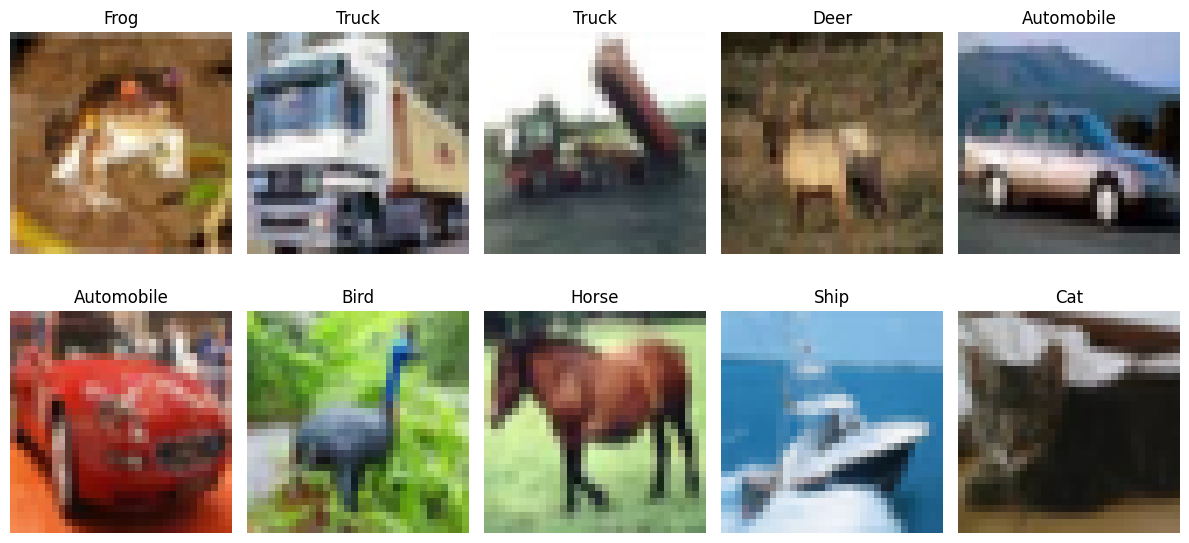

In [4]:

class_names = [
    'Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck'
]

plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

The pixel values of the images range from 0 to 255. To improve training efficiency and model convergence, the values are normalized to the range [0,1].

In [5]:

x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

print("Minimum Pixel Value:", x_train_norm.min())
print("Maximum Pixel Value:", x_train_norm.max())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


## 5. Building an Artificial Neural Network (ANN)

An Artificial Neural Network (ANN) is a fully connected neural network that learns patterns from input data through multiple dense layers. In this project, ANN serves as a baseline model for image classification on the CIFAR-10 dataset.

In [6]:
ann_model = Sequential([
    Flatten(input_shape=(32,32,3)),

    Dense(512, activation='relu'),
    Dropout(0.3),

    Dense(256, activation='relu'),

    Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Training the ANN Model

The ANN model is trained using the Adam optimizer and Sparse Categorical Crossentropy loss function. A validation split is used to monitor model performance during training.

In [7]:
ann_history = ann_model.fit(
    x_train_norm,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.2706 - loss: 1.9993 - val_accuracy: 0.3356 - val_loss: 1.8293
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.3268 - loss: 1.8502 - val_accuracy: 0.3708 - val_loss: 1.7669
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3451 - loss: 1.7982 - val_accuracy: 0.3712 - val_loss: 1.7513
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3598 - loss: 1.7597 - val_accuracy: 0.3956 - val_loss: 1.7078
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3702 - loss: 1.7320 - val_accuracy: 0.4040 - val_loss: 1.6761
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.3800 - loss: 1.7168 - val_accuracy: 0.3888 - val_loss: 1.6915
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.3859 - loss: 1.6906 - val_accuracy: 0.4128 - val_loss: 1.6724
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3897 - loss: 1.6726 - 

## 7. Evaluating ANN Performance

The trained ANN model is evaluated on the test dataset to measure its classification accuracy.

In [8]:
ann_test_loss, ann_test_acc = ann_model.evaluate(
    x_test_norm,
    y_test
)

print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4389 - loss: 1.5994
ANN Test Accuracy: 0.4388999938964844


## 8. Building a Convolutional Neural Network (CNN)

Convolutional Neural Networks (CNNs) are specifically designed for image classification tasks. They automatically learn spatial features such as edges, textures, and shapes, making them more effective than traditional Artificial Neural Networks for image data.

In [9]:
cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,626,826 (6.21 MB)

 Trainable params: 1,626,634 (6.21 MB)

 Non-trainable params: 192 (768.00 B)

## 9. Training the CNN Model

The CNN model is trained on the CIFAR-10 dataset to learn image features and improve classification performance compared to the ANN model.

In [11]:
cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 195s 278ms/step - accuracy: 0.8393 - loss: 0.4470 - val_accuracy: 0.6678 - val_loss: 1.2121
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 198s 281ms/step - accuracy: 0.8520 - loss: 0.4158 - val_accuracy: 0.6860 - val_loss: 1.2164
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 200s 284ms/step - accuracy: 0.8641 - loss: 0.3817 - val_accuracy: 0.6858 - val_loss: 1.3019
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 195s 277ms/step - accuracy: 0.8698 - loss: 0.3590 - val_accuracy: 0.6826 - val_loss: 1.2619
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 196s 278ms/step - accuracy: 0.8800 - loss: 0.3342 - val_accuracy: 0.6624 - val_loss: 1.3584
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 193s 275ms/step - accuracy: 0.8858 - loss: 0.3191 - val_accuracy: 0.6686 - val_loss: 1.4601
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 204s 277ms/step - accuracy: 0.8910 - loss: 0.3047 - val_accuracy: 0.6784 - val_loss: 1.4791
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 197s 280ms/step - accuracy: 0.8928 -

## 10. Evaluating CNN Performance

The CNN model is evaluated on the test dataset to determine its classification accuracy on unseen data.

In [12]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.6901 - loss: 1.3284
CNN Test Accuracy: 0.6901000142097473


In [13]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc
    ]
})

comparison

,Model,Test Accuracy
0,ANN,0.4389
1,CNN,0.6901


## 12. Validation Accuracy Comparison

The following graph compares the validation accuracy of ANN and CNN models during training.

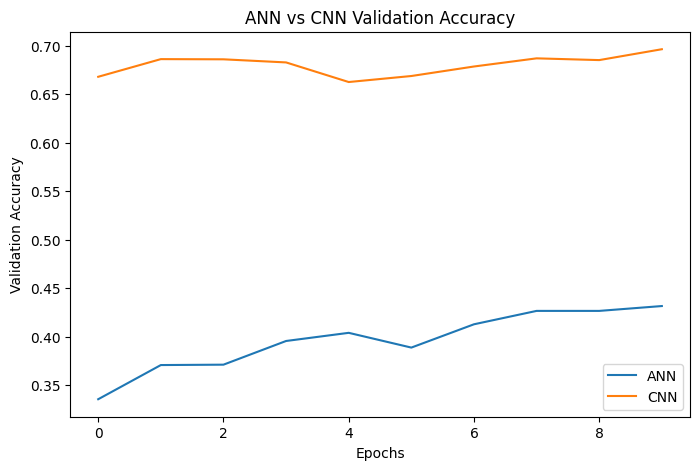

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    ann_history.history['val_accuracy'],
    label='ANN'
)

plt.plot(
    cnn_history.history['val_accuracy'],
    label='CNN'
)

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()

plt.show()

## 14. Final Results

The final test accuracies obtained from both models are displayed below.

In [16]:
print("ANN Test Accuracy :", round(ann_test_acc * 100, 2), "%")
print("CNN Test Accuracy :", round(cnn_test_acc * 100, 2), "%")

ANN Test Accuracy : 43.89 %
CNN Test Accuracy : 69.01 %


## 15. Conclusion

This project explored image classification on the CIFAR-10 dataset using both Artificial Neural Networks (ANN) and Convolutional Neural Networks (CNN).

### Key Observations

- ANN achieved reasonable performance but struggled to capture complex image features.
- CNN significantly outperformed ANN by learning spatial patterns directly from images.
- Validation accuracy consistently remained higher for CNN throughout training.
- CNN proved to be a more effective architecture for image classification tasks.

### Final Outcome

The CNN model achieved substantially higher classification accuracy compared to the ANN model, making it the preferred approach for CIFAR-10 image classification.